# Analisis Efektivitas Kampanye Personal Loan untuk Optimalisasi Strategi Pemasaran Bank
by : Nadhif Fajrul Minan


# 1️⃣ Business Understanding

## Latar Belakang

Thera Bank merupakan sebuah institusi perbankan yang ingin meningkatkan keberhasilan pemasaran produk **Personal Loan** kepada nasabah yang telah memiliki hubungan dengan bank.

Pada kampanye pemasaran sebelumnya, hanya **480 dari 5.000 nasabah (9,6%)** yang menerima penawaran pinjaman. Tingkat konversi tersebut menunjukkan bahwa sebagian besar biaya pemasaran masih digunakan untuk menawarkan produk kepada nasabah yang belum tentu memiliki minat terhadap produk tersebut.

Melalui analisis data ini, diharapkan dapat diidentifikasi karakteristik nasabah yang memiliki peluang lebih tinggi menerima penawaran Personal Loan sehingga strategi pemasaran dapat dilakukan secara lebih efektif, tepat sasaran, dan efisien.

---

## Permasalahan Bisnis

Beberapa pertanyaan bisnis yang ingin dijawab pada proyek ini antara lain:

- Bagaimana karakteristik nasabah yang menerima Personal Loan?
- Faktor apa saja yang berhubungan dengan penerimaan Personal Loan?
- Produk perbankan apa yang paling berpengaruh terhadap keberhasilan kampanye?
- Bagaimana strategi pemasaran yang dapat meningkatkan tingkat konversi?

---

## Tujuan Analisis

Analisis ini bertujuan untuk:

- Memahami karakteristik nasabah berdasarkan data yang tersedia.
- Mengidentifikasi faktor yang memengaruhi penerimaan Personal Loan.
- Menemukan insight yang dapat membantu pengambilan keputusan bisnis.
- Memberikan rekomendasi strategi pemasaran berbasis data.

# 2️⃣ Import Library

Pada tahap ini dilakukan import seluruh library yang diperlukan untuk proses pengolahan data, visualisasi, dan analisis.

In [48]:
# ============================================================
# DATA ANALYST PORTFOLIO
# Personal Loan Campaign Analysis
# ============================================================

# ============================================================
# 1. BASIC LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import math

# ============================================================
# 2. DATA MANIPULATION
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# 3. DATA VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

# ============================================================
# 4. STATISTICAL ANALYSIS
# ============================================================

from scipy import stats

from scipy.stats import (
    chi2_contingency,
    pearsonr,
    spearmanr,
    pointbiserialr
)

# ============================================================
# 5. DATA PREPROCESSING
# ============================================================

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

# ============================================================
# 6. MACHINE LEARNING (Supporting Analysis)
# ============================================================

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

# ============================================================
# 7. MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# ============================================================
# 8. NOTEBOOK SETTINGS
# ============================================================

# Display seluruh kolom
pd.set_option("display.max_columns", None)

# Display seluruh baris (opsional)
pd.set_option("display.max_rows", 100)

# Format angka
pd.options.display.float_format = "{:,.2f}".format

# Style visualisasi
sns.set_theme(
    style="whitegrid",
    palette="Blues"
)

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Plotly Theme
import plotly.io as pio
pio.templates.default = "plotly_white"

# Random Seed
RANDOM_STATE = 42

print("="*60)
print("📊 Personal Loan Campaign Analysis")
print("✅ Library berhasil diimpor")
print("="*60)

📊 Personal Loan Campaign Analysis
✅ Library berhasil diimpor



# 3️⃣ Load Dataset

Dataset dimuat ke dalam DataFrame menggunakan library Pandas agar dapat dilakukan proses eksplorasi dan analisis lebih lanjut.

In [49]:
# ============================================================
# LOAD DATASET
# ============================================================

# Membaca dataset
df = pd.read_csv(
    "/kaggle/input/datasets/teertha/personal-loan-modeling/Bank_Personal_Loan_Modelling.csv"
)

# Menampilkan informasi keberhasilan
print("Dataset berhasil dimuat.")
print(f"Jumlah Baris  : {df.shape[0]:,}")
print(f"Jumlah Kolom  : {df.shape[1]}")

# Menampilkan 5 data pertama
df.head()

Dataset berhasil dimuat.
Jumlah Baris  : 5,000
Jumlah Kolom  : 14


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.00,2,0,0,0,0,0,1


# 4️⃣ Data Understanding

Tahap ini bertujuan untuk memahami struktur dataset, tipe data, jumlah observasi, serta informasi pada setiap variabel sebelum dilakukan analisis lebih lanjut.

## 4.1 Dimensi Dataset

Tahap ini bertujuan untuk mengetahui jumlah observasi (baris) dan jumlah variabel (kolom) yang terdapat pada dataset.

In [50]:
print("="*50)
print("Dimensi Dataset")
print("="*50)

print(f"Jumlah Baris  : {df.shape[0]:,}")
print(f"Jumlah Kolom  : {df.shape[1]}")

Dimensi Dataset
Jumlah Baris  : 5,000
Jumlah Kolom  : 14


## 4.2 Menampilkan Sampel Data

Lima baris pertama ditampilkan untuk memberikan gambaran awal mengenai isi dataset serta memastikan data berhasil dimuat dengan benar.

In [51]:
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.00,2,0,0,0,0,0,1


## 4.3 Informasi Dataset

Tahap ini digunakan untuk mengetahui tipe data setiap variabel, jumlah data yang tersedia, serta penggunaan memori dataset.

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


## 4.4 Statistik Deskriptif

Statistik deskriptif memberikan gambaran umum mengenai distribusi data numerik, seperti nilai rata-rata, standar deviasi, nilai minimum, kuartil, dan nilai maksimum.

In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,"5,000.00","2,500.50","1,443.52",1.00,"1,250.75","2,500.50","3,750.25","5,000.00"
Age,"5,000.00",45.34,11.46,23.00,35.00,45.00,55.00,67.00
Experience,"5,000.00",20.10,11.47,-3.00,10.00,20.00,30.00,43.00
Income,"5,000.00",73.77,46.03,8.00,39.00,64.00,98.00,224.00
ZIP Code,"5,000.00","93,152.50","2,121.85","9,307.00","91,911.00","93,437.00","94,608.00","96,651.00"
Family,"5,000.00",2.40,1.15,1.00,1.00,2.00,3.00,4.00
CCAvg,"5,000.00",1.94,1.75,0.00,0.70,1.50,2.50,10.00
Education,"5,000.00",1.88,0.84,1.00,1.00,2.00,3.00,3.00
Mortgage,"5,000.00",56.50,101.71,0.00,0.00,0.00,101.00,635.00
Personal Loan,"5,000.00",0.10,0.29,0.00,0.00,0.00,0.00,1.00


## 4.5 Pemeriksaan Missing Value

Pemeriksaan dilakukan untuk memastikan tidak terdapat nilai yang hilang (*Missing Value*) pada setiap variabel.

In [54]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Jumlah Missing")
)

missing["Persentase (%)"] = (
    missing["Jumlah Missing"]
    / len(df)
    *100
)

missing

,Jumlah Missing,Persentase (%)
ID,0,0.00
Age,0,0.00
Experience,0,0.00
Income,0,0.00
ZIP Code,0,0.00
Family,0,0.00
CCAvg,0,0.00
Education,0,0.00
Mortgage,0,0.00
Personal Loan,0,0.00


## 4.6 Pemeriksaan Data Duplikat

Tahap ini bertujuan untuk memastikan tidak terdapat data yang tercatat lebih dari satu kali sehingga hasil analisis tetap akurat.

In [55]:
duplicate = df.duplicated().sum()

print(f"Jumlah Data Duplikat : {duplicate}")

Jumlah Data Duplikat : 0


## 4.7 Pemeriksaan Nilai Unik

Jumlah nilai unik pada setiap variabel diperiksa untuk memahami karakteristik masing-masing variabel serta mengidentifikasi variabel kategorikal dan numerik.

In [56]:
unique = pd.DataFrame({
    "Variabel": df.columns,
    "Jumlah Nilai Unik": df.nunique().values
})

unique

,Variabel,Jumlah Nilai Unik
0,ID,5000
1,Age,45
2,Experience,47
3,Income,162
4,ZIP Code,467
5,Family,4
6,CCAvg,108
7,Education,3
8,Mortgage,347
9,Personal Loan,2


## 4.8 Ringkasan Dataset

Sebagai penutup tahap *Data Understanding*, berikut disajikan ringkasan kualitas dataset yang akan digunakan pada proses analisis selanjutnya.

In [57]:
summary = pd.DataFrame({
    "Informasi": [
        "Jumlah Baris",
        "Jumlah Kolom",
        "Missing Value",
        "Data Duplikat",
        "Variabel Numerik",
        "Variabel Kategorikal"
    ],
    "Hasil": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        len(df.select_dtypes(include=np.number).columns),
        len(df.select_dtypes(exclude=np.number).columns)
    ]
})

summary

,Informasi,Hasil
0,Jumlah Baris,5000
1,Jumlah Kolom,14
2,Missing Value,0
3,Data Duplikat,0
4,Variabel Numerik,14
5,Variabel Kategorikal,0


# 5️⃣ Data Cleaning

Tahap ini bertujuan untuk meningkatkan kualitas data agar siap digunakan pada proses analisis. Beberapa proses yang dilakukan meliputi penghapusan variabel yang tidak relevan, standarisasi format data, koreksi nilai yang tidak valid, serta pembuatan variabel baru yang dapat memperkaya proses analisis.

Output dari tahap ini adalah dataset yang lebih bersih, konsisten, dan mudah diinterpretasikan.

## 5.1 Menghapus Kolom ID

Kolom **ID** hanya berfungsi sebagai identitas unik setiap nasabah dan tidak mengandung informasi yang dapat digunakan dalam proses analisis. Oleh karena itu, kolom ini dihapus agar analisis lebih berfokus pada variabel yang relevan.

In [58]:
# Menghapus kolom ID
df.drop(columns="ID", inplace=True)

print("Kolom ID berhasil dihapus.")
df.head()

Kolom ID berhasil dihapus.


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.60,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.50,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.00,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.70,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.00,2,0,0,0,0,0,1


## 5.2 Transformasi dan Standarisasi Data

Pada tahap ini dilakukan beberapa proses transformasi untuk meningkatkan kualitas data, antara lain:

- Mengubah format nilai **CCAvg** menjadi numerik.
- Mengonversi pengeluaran kartu kredit bulanan menjadi estimasi tahunan.
- Mengoreksi nilai negatif pada variabel **Experience**.
- Mengubah kode tingkat pendidikan menjadi label yang lebih mudah dipahami.

In [59]:
# =====================================================
# Transformasi Variabel
# =====================================================

# 1. Mengubah format CCAvg menjadi numerik
df["CCAvg"] = (
    df["CCAvg"]
    .astype(str)
    .str.replace("/", ".", regex=False)
    .astype(float)
)

# 2. Konversi pengeluaran bulanan menjadi tahunan
df["CCAvg"] = df["CCAvg"] * 12

# 3. Menghilangkan nilai negatif pada Experience
df["Experience"] = df["Experience"].abs()

# 4. Mengubah kode pendidikan menjadi label
education_map = {
    1: "Sarjana",
    2: "Pascasarjana",
    3: "Profesional"
}

df["Education"] = df["Education"].map(education_map)

print("Transformasi data berhasil dilakukan.")

Transformasi data berhasil dilakukan.


## 5.3 Feature Engineering

Selain membersihkan data, dibuat beberapa variabel baru untuk mempermudah proses segmentasi nasabah pada tahap analisis.

Variabel yang ditambahkan meliputi:

- Kelompok usia.
- Kategori pendapatan.
- Kategori pengeluaran kartu kredit.

In [60]:
# =====================================================
# Feature Engineering
# =====================================================

# Kelompok Usia
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[20,30,40,50,60,70],
    labels=[
        "20–29 Tahun",
        "30–39 Tahun",
        "40–49 Tahun",
        "50–59 Tahun",
        "60–69 Tahun"
    ],
    right=False
)

# Kategori Pendapatan
df["Income Category"] = pd.cut(
    df["Income"],
    bins=[0,40,80,120,160,np.inf],
    labels=[
        "Rendah",
        "Menengah",
        "Menengah Atas",
        "Tinggi",
        "Sangat Tinggi"
    ]
)

# Kategori Pengeluaran Kartu Kredit
df["CCAvg Category"] = pd.qcut(
    df["CCAvg"],
    q=4,
    labels=[
        "Rendah",
        "Sedang",
        "Tinggi",
        "Sangat Tinggi"
    ]
)

print("Feature Engineering berhasil dilakukan.")

Feature Engineering berhasil dilakukan.


## 5.4 Validasi Hasil Data Cleaning

Tahap terakhir dilakukan untuk memastikan seluruh proses pembersihan data telah berhasil dilakukan dan dataset siap digunakan pada proses eksplorasi data.

In [61]:
# =====================================================
# Ringkasan Dataset Setelah Data Cleaning
# =====================================================

summary = pd.DataFrame({
    "Pemeriksaan": [
        "Jumlah Baris",
        "Jumlah Kolom",
        "Missing Value",
        "Data Duplikat",
        "Experience Negatif",
        "Kolom Baru"
    ],
    "Hasil": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["Experience"] < 0).sum(),
        "Age Group, Income Category, CCAvg Category"
    ]
})

display(summary)

print("\nDataset siap digunakan untuk Exploratory Data Analysis (EDA).")

df.head()

,Pemeriksaan,Hasil
0,Jumlah Baris,5000
1,Jumlah Kolom,16
2,Missing Value,0
3,Data Duplikat,0
4,Experience Negatif,0
5,Kolom Baru,"Age Group, Income Category, CCAvg Category"



Dataset siap digunakan untuk Exploratory Data Analysis (EDA).


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Age Group,Income Category,CCAvg Category
0,25,1,49,91107,4,19.20,Sarjana,0,0,1,0,0,0,20–29 Tahun,Menengah,Tinggi
1,45,19,34,90089,3,18.00,Sarjana,0,0,1,0,0,0,40–49 Tahun,Rendah,Sedang
2,39,15,11,94720,1,12.00,Sarjana,0,0,0,0,0,0,30–39 Tahun,Rendah,Sedang
3,35,9,100,94112,1,32.40,Pascasarjana,0,0,0,0,0,0,30–39 Tahun,Menengah Atas,Sangat Tinggi
4,35,8,45,91330,4,12.00,Pascasarjana,0,0,0,0,0,1,30–39 Tahun,Menengah,Sedang


# 🛠 Utility Function

Agar proses analisis lebih efisien dan konsisten, dibuat beberapa fungsi yang akan digunakan berulang kali selama proses visualisasi dan analisis data.

Pendekatan ini membuat kode lebih ringkas, mudah dipelihara, serta menghindari penulisan kode yang berulang (*Don't Repeat Yourself*).

In [62]:
def plot_numeric(df, column, bins=30):

    fig, ax = plt.subplots(1,2, figsize=(14,5))

    sns.histplot(
        data=df,
        x=column,
        bins=bins,
        kde=True,
        color="#2563eb",
        ax=ax[0]
    )

    ax[0].set_title(f"Distribusi {column}")

    sns.boxplot(
        data=df,
        x=column,
        color="#93c5fd",
        ax=ax[1]
    )

    ax[1].set_title(f"Boxplot {column}")

    plt.tight_layout()
    plt.show()

In [63]:
def plot_categorical(df, column):

    plt.figure(figsize=(8,5))

    order = df[column].value_counts().index

    ax = sns.countplot(
        data=df,
        x=column,
        order=order,
        palette="Blues_r"
    )

    for p in ax.patches:

        ax.annotate(
            f"{int(p.get_height())}",
            (
                p.get_x()+p.get_width()/2,
                p.get_height()
            ),
            ha="center",
            va="bottom"
        )

    plt.title(f"Distribusi {column}")

    plt.xticks(rotation=15)

    plt.show()

In [64]:
def plot_target(df, feature, target="Personal Loan"):

    plt.figure(figsize=(8,5))

    temp = (
        df.groupby(feature)[target]
        .mean()
        .sort_values(ascending=False)
        *100
    )

    ax = sns.barplot(
        x=temp.index,
        y=temp.values,
        palette="Blues"
    )

    for p in ax.patches:

        ax.annotate(
            f"{p.get_height():.1f}%",
            (
                p.get_x()+p.get_width()/2,
                p.get_height()
            ),
            ha="center",
            va="bottom"
        )

    plt.ylabel("Acceptance Rate (%)")

    plt.xlabel(feature)

    plt.title(f"Acceptance Rate berdasarkan {feature}")

    plt.show()

In [65]:
def correlation_heatmap(df):

    plt.figure(figsize=(12,8))

    sns.heatmap(
        df.select_dtypes(include=np.number).corr(),
        annot=True,
        cmap="Blues",
        fmt=".2f"
    )

    plt.title("Correlation Matrix")

    plt.show()

In [66]:
def summary_numeric(df):

    return (
        df.describe()
        .T
        .style
        .background_gradient(cmap="Blues")
    )

In [67]:
def missing_summary(df):

    miss = pd.DataFrame({

        "Missing":df.isnull().sum(),

        "Persentase":round(
            df.isnull().mean()*100,
            2
        )

    })

    return miss.sort_values(
        "Missing",
        ascending=False
    )

In [68]:
def summary_category(df,column):

    temp = pd.DataFrame({

        "Jumlah":df[column].value_counts(),

        "Persentase (%)":
        round(
            df[column].value_counts(normalize=True)*100,
            2
        )

    })

    return temp

In [69]:
def analyze_target(df, feature, target="Personal Loan"):
    """
    Analisis hubungan antara feature dengan Personal Loan.
    Otomatis memilih visualisasi berdasarkan tipe data.
    """

    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from IPython.display import display, Markdown

    temp = df.copy()

    # Label target agar mudah dibaca
    target_label = {
        0: "Tidak Menerima",
        1: "Menerima"
    }

    temp[target] = temp[target].map(target_label)

    print("=" * 80)
    print(f"Analisis : {feature}")
    print("=" * 80)

    # ===================================================
    # NUMERIC FEATURE
    # ===================================================
    if pd.api.types.is_numeric_dtype(df[feature]):

        fig, ax = plt.subplots(1,2, figsize=(14,5))

        sns.boxplot(
            data=temp,
            x=target,
            y=feature,
            palette="Blues",
            ax=ax[0]
        )

        ax[0].set_title(f"{feature} berdasarkan Personal Loan")

        sns.violinplot(
            data=temp,
            x=target,
            y=feature,
            palette="Blues",
            ax=ax[1]
        )

        ax[1].set_title(f"Distribusi {feature}")

        plt.tight_layout()

        plt.show()

        summary = (
            df.groupby(target)[feature]
            .agg([
                "count",
                "mean",
                "median",
                "std",
                "min",
                "max"
            ])
            .rename(index={
                0:"Tidak Menerima",
                1:"Menerima"
            })
            .round(2)
        )

        display(summary)

        mean0 = summary.loc["Tidak Menerima","mean"]
        mean1 = summary.loc["Menerima","mean"]

        if mean1 > mean0:

            display(Markdown(
                f"""
> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **{feature}**
lebih tinggi dibandingkan nasabah
yang tidak menerima.
"""
            ))

        else:

            display(Markdown(
                f"""
> **Insight**

Nasabah yang menerima Personal Loan
cenderung memiliki rata-rata
**{feature}**
lebih rendah.
"""
            ))

    # ===================================================
    # CATEGORICAL FEATURE
    # ===================================================
    else:

        cross = pd.crosstab(
            temp[feature],
            temp[target],
            normalize="index"
        ) *100

        ax = cross.plot(
            kind="bar",
            stacked=True,
            figsize=(9,5),
            colormap="Blues"
        )

        for container in ax.containers:

            labels = [
                f"{v:.1f}%"
                if v>0
                else ""
                for v in container.datavalues
            ]

            ax.bar_label(
                container,
                labels=labels,
                label_type="center"
            )

        plt.title(
            f"Penerimaan Personal Loan berdasarkan {feature}"
        )

        plt.ylabel("Persentase (%)")

        plt.tight_layout()

        plt.show()

        summary = (
            pd.crosstab(
                df[feature],
                df[target],
                normalize="index"
            )*100
        ).round(2)

        summary.columns=[
            "Tidak Menerima (%)",
            "Menerima (%)"
        ]

        display(summary)

        highest = summary["Menerima (%)"].idxmax()

        rate = summary["Menerima (%)"].max()

        display(Markdown(
            f"""
> **Insight**

Kelompok **{highest}**
memiliki tingkat penerimaan Personal Loan
tertinggi yaitu
**{rate:.1f}%**.
"""
        ))

# 6️⃣ Descriptive Statistics

Statistik deskriptif digunakan untuk memberikan gambaran umum mengenai karakteristik data melalui nilai rata-rata, median, standar deviasi, nilai minimum, dan maksimum.

In [70]:
# Ringkasan statistik variabel numerik
numeric_summary = (
    df.describe()
      .T
      .rename(columns={
          "count":"Jumlah Data",
          "mean":"Rata-rata",
          "std":"Standar Deviasi",
          "min":"Minimum",
          "25%":"Kuartil 1",
          "50%":"Median",
          "75%":"Kuartil 3",
          "max":"Maksimum"
      })
      .round(2)
)

numeric_summary.style.background_gradient(cmap="Blues")

,Jumlah Data,Rata-rata,Standar Deviasi,Minimum,Kuartil 1,Median,Kuartil 3,Maksimum
Age,5000.000000,45.340000,11.460000,23.000000,35.000000,45.000000,55.000000,67.000000
Experience,5000.000000,20.130000,11.420000,0.000000,10.000000,20.000000,30.000000,43.000000
Income,5000.000000,73.770000,46.030000,8.000000,39.000000,64.000000,98.000000,224.000000
ZIP Code,5000.000000,93152.500000,2121.850000,9307.000000,91911.000000,93437.000000,94608.000000,96651.000000
Family,5000.000000,2.400000,1.150000,1.000000,1.000000,2.000000,3.000000,4.000000
CCAvg,5000.000000,23.260000,20.970000,0.000000,8.400000,18.000000,30.000000,120.000000
Mortgage,5000.000000,56.500000,101.710000,0.000000,0.000000,0.000000,101.000000,635.000000
Personal Loan,5000.000000,0.100000,0.290000,0.000000,0.000000,0.000000,0.000000,1.000000
Securities Account,5000.000000,0.100000,0.310000,0.000000,0.000000,0.000000,0.000000,1.000000
CD Account,5000.000000,0.060000,0.240000,0.000000,0.000000,0.000000,0.000000,1.000000


In [71]:
# 6.2 Statistik Variabel Kategorikal
categorical_summary = pd.DataFrame({
    "Variabel": df.select_dtypes(include=["object","category"]).columns,
    "Jumlah Kategori": [
        df[col].nunique()
        for col in df.select_dtypes(include=["object","category"]).columns
    ]
})

categorical_summary

,Variabel,Jumlah Kategori
0,Education,3
1,Age Group,5
2,Income Category,5
3,CCAvg Category,4


In [72]:
# Ringkasan distribusi target
loan_summary = (
    df["Personal Loan"]
    .replace({
        0: "Tidak Menerima",
        1: "Menerima"
    })
    .value_counts()
    .rename_axis("Status Personal Loan")
    .reset_index(name="Jumlah Nasabah")
)

loan_summary["Persentase (%)"] = (
    loan_summary["Jumlah Nasabah"]
    / loan_summary["Jumlah Nasabah"].sum()
    * 100
).round(2)

loan_summary

,Status Personal Loan,Jumlah Nasabah,Persentase (%)
0,Tidak Menerima,4520,90.40
1,Menerima,480,9.60


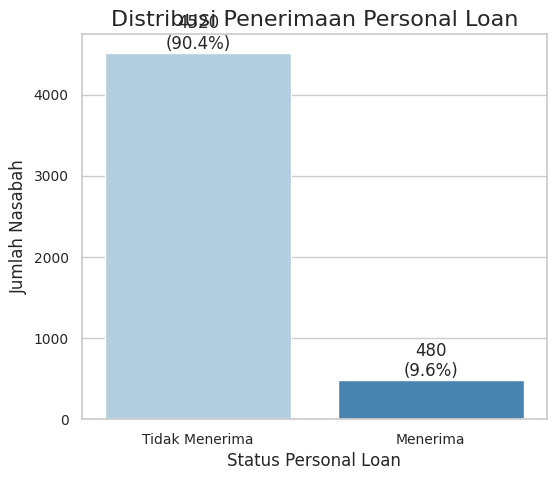

In [73]:
def plot_target_distribution(df):

    temp = df.copy()

    temp["Personal Loan"] = temp["Personal Loan"].map({
        0: "Tidak Menerima",
        1: "Menerima"
    })

    plt.figure(figsize=(6,5))

    ax = sns.countplot(
        data=temp,
        x="Personal Loan",
        palette="Blues"
    )

    total = len(temp)

    for p in ax.patches:

        percentage = (
            p.get_height()/total
        )*100

        ax.annotate(
            f"{int(p.get_height())}\n({percentage:.1f}%)",
            (
                p.get_x()+p.get_width()/2,
                p.get_height()
            ),
            ha="center",
            va="bottom"
        )

    plt.title("Distribusi Penerimaan Personal Loan")

    plt.xlabel("Status Personal Loan")

    plt.ylabel("Jumlah Nasabah")

    plt.show()

plot_target_distribution(df)


In [74]:
summary = pd.DataFrame({
    "Informasi":[
        "Jumlah Observasi",
        "Jumlah Variabel",
        "Variabel Numerik",
        "Variabel Kategorikal",
        "Rata-rata Pendapatan",
        "Median Pendapatan",
        "Rata-rata Pengeluaran Kartu Kredit",
        "Persentase Penerimaan Personal Loan"
    ],
    "Nilai":[
        len(df),
        df.shape[1],
        len(df.select_dtypes(include=np.number).columns),
        len(df.select_dtypes(exclude=np.number).columns),
        round(df["Income"].mean(),2),
        round(df["Income"].median(),2),
        round(df["CCAvg"].mean(),2),
        round(df["Personal Loan"].mean()*100,2)
    ]
})

summary

,Informasi,Nilai
0,Jumlah Observasi,"5,000.00"
1,Jumlah Variabel,16.00
2,Variabel Numerik,12.00
3,Variabel Kategorikal,4.00
4,Rata-rata Pendapatan,73.77
5,Median Pendapatan,64.00
6,Rata-rata Pengeluaran Kartu Kredit,23.26
7,Persentase Penerimaan Personal Loan,9.60


# 7️⃣ Exploratory Data Analysis

Tahap ini bertujuan mengeksplorasi data untuk menemukan pola, distribusi, hubungan antar variabel, serta insight awal yang dapat membantu menjawab permasalahan bisnis.

## 7.1  Customer Demographic Analysis

Pada tahap ini dilakukan analisis terhadap karakteristik demografis nasabah untuk mengetahui profil pelanggan yang menjadi target utama produk Personal Loan.

Variabel yang dianalisis meliputi:

- Usia
- Pengalaman kerja
- Jumlah anggota keluarga
- Tingkat pendidikan

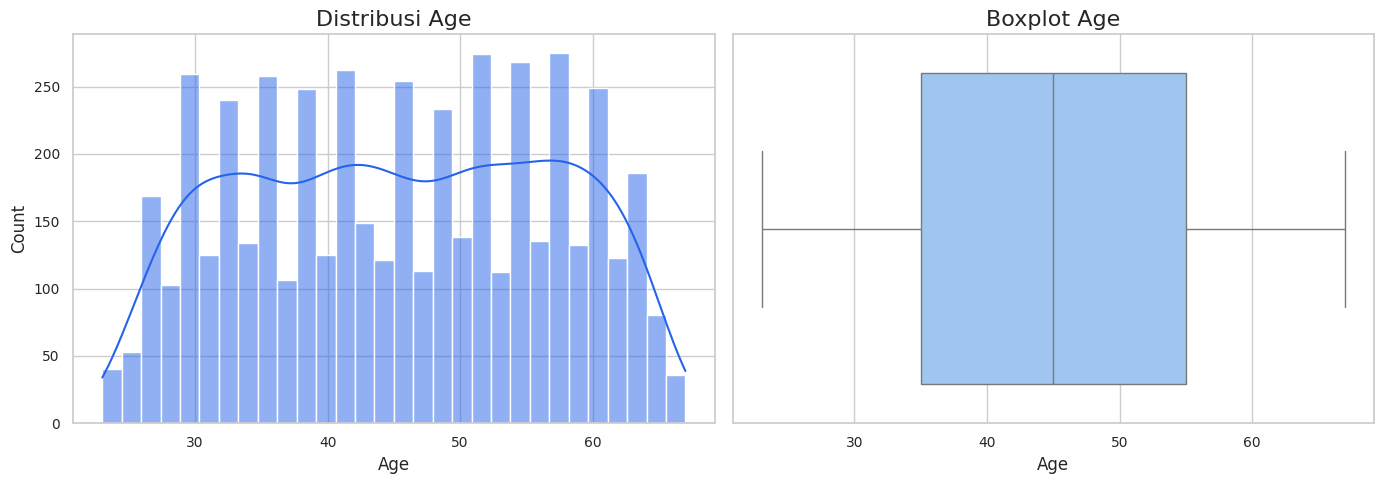

In [75]:
plot_numeric(df, "Age")


### Insight

Distribusi usia digunakan untuk mengetahui rentang usia dominan nasabah. Informasi ini membantu bank memahami kelompok usia yang menjadi mayoritas pelanggan sehingga strategi pemasaran dapat disesuaikan dengan karakteristik usia tersebut.

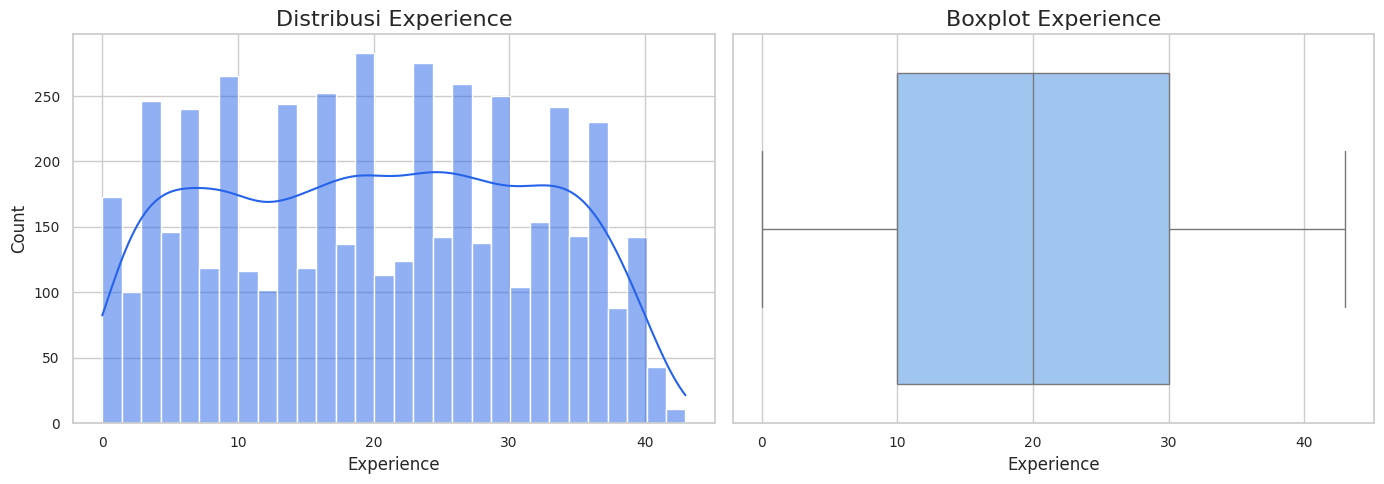

In [76]:
# Pengalaman Kerja
plot_numeric(df, "Experience")

tambahkan insight

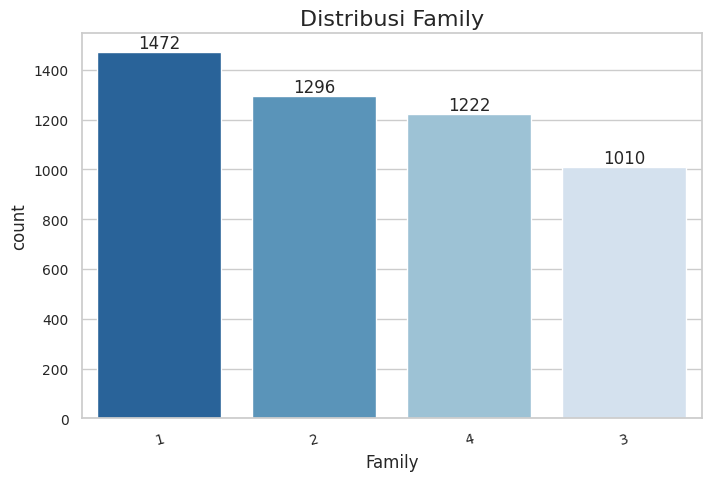

In [77]:
# Jumlah Anggota Keluarga
plot_categorical(df, "Family")

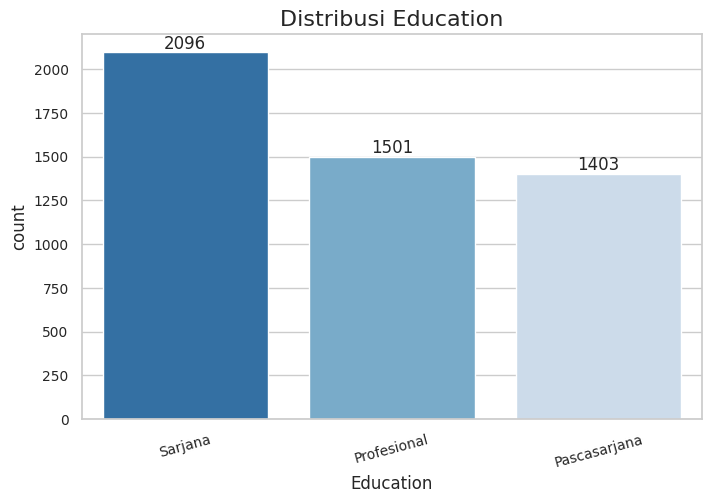

In [78]:
# Pendidikan
plot_categorical(df, "Education")

### Kesimpulan

Mayoritas nasabah berada pada usia produktif dengan tingkat pendidikan yang relatif baik. Karakteristik ini menunjukkan bahwa sebagian besar pelanggan memiliki potensi kebutuhan finansial yang cukup tinggi sehingga menjadi segmen yang menarik bagi produk Personal Loan.

## 7.2 Financial Profile Analysis

Tahap ini bertujuan menganalisis kondisi finansial nasabah yang berpotensi memengaruhi keputusan dalam menerima penawaran Personal Loan.

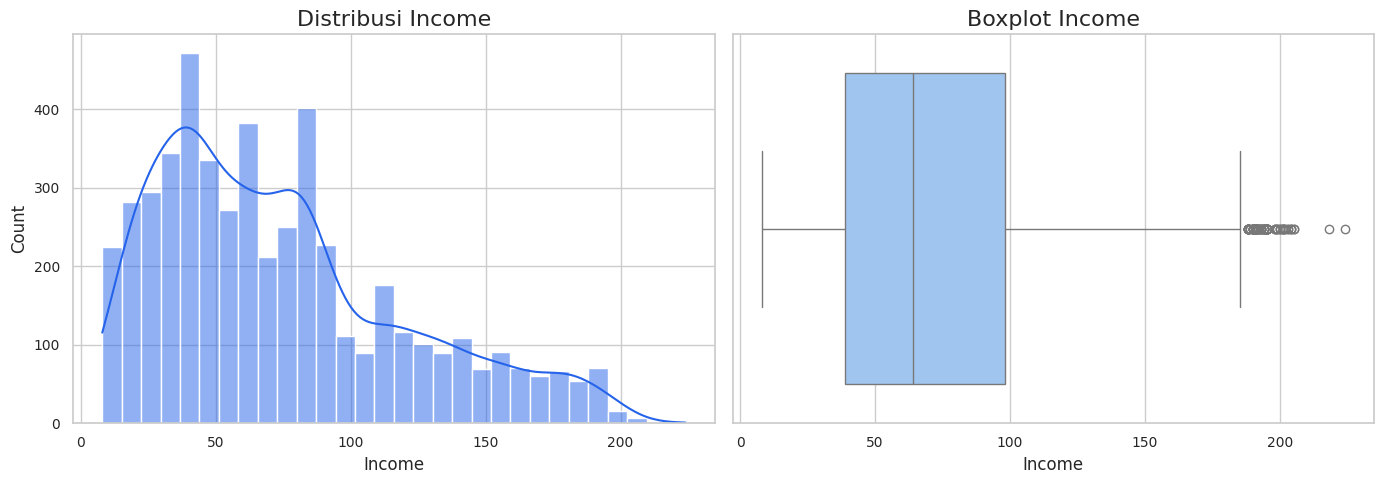

In [79]:
plot_numeric(df, "Income")


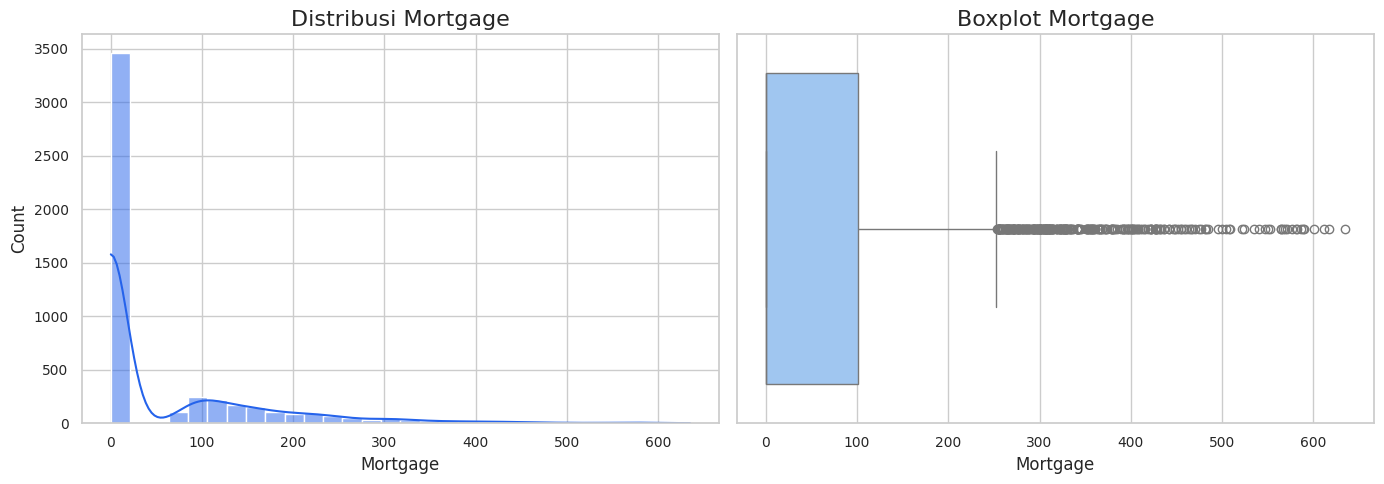

In [80]:
plot_numeric(df, "Mortgage")

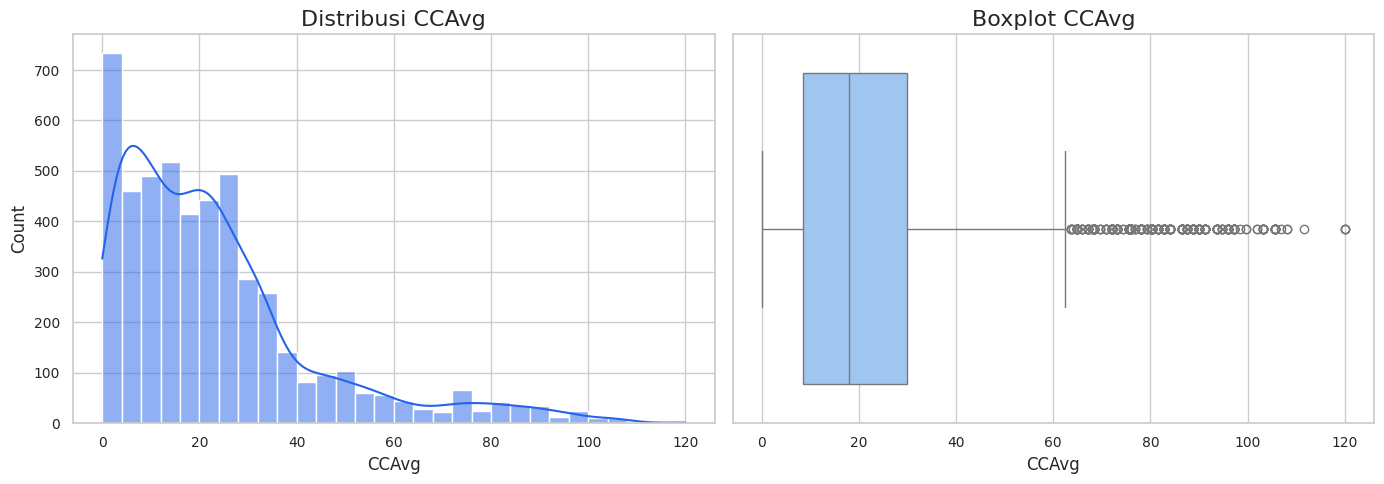

In [81]:
# Pengeluaran Kartu Kredit
plot_numeric(df, "CCAvg")

### Kesimpulan

Sebagian besar nasabah memiliki kondisi finansial yang cukup beragam, baik dari sisi pendapatan maupun pengeluaran kartu kredit. Variasi ini menjadi dasar untuk mengidentifikasi kelompok nasabah yang memiliki potensi lebih besar dalam menerima penawaran Personal Loan.

## 7.3 Banking Product Analysis

Analisis ini bertujuan untuk mengetahui tingkat penggunaan berbagai produk dan layanan yang disediakan bank.

Pemanfaatan layanan bank dapat mencerminkan tingkat keterlibatan (*customer engagement*) nasabah terhadap institusi perbankan.

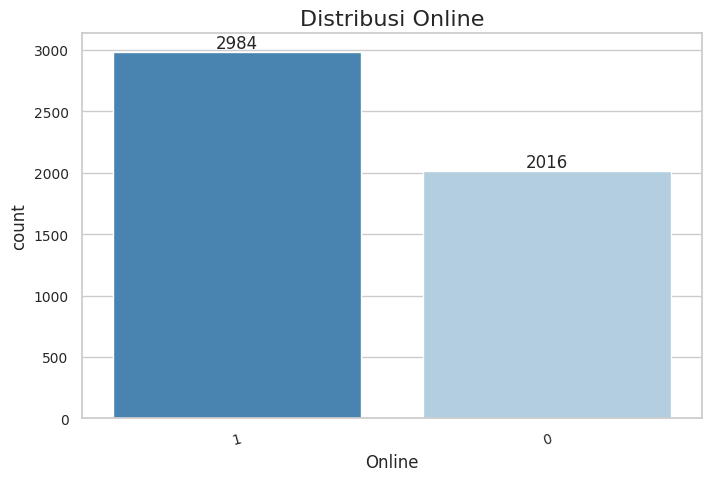

In [82]:
plot_categorical(df, "Online")

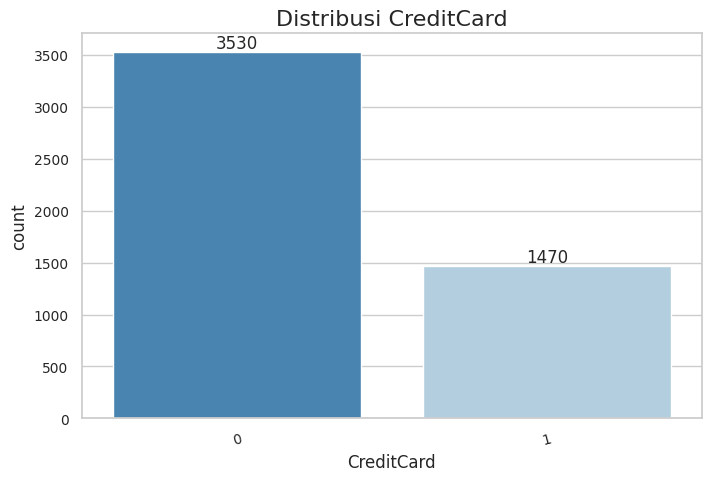

In [83]:
plot_categorical(df, "CreditCard")

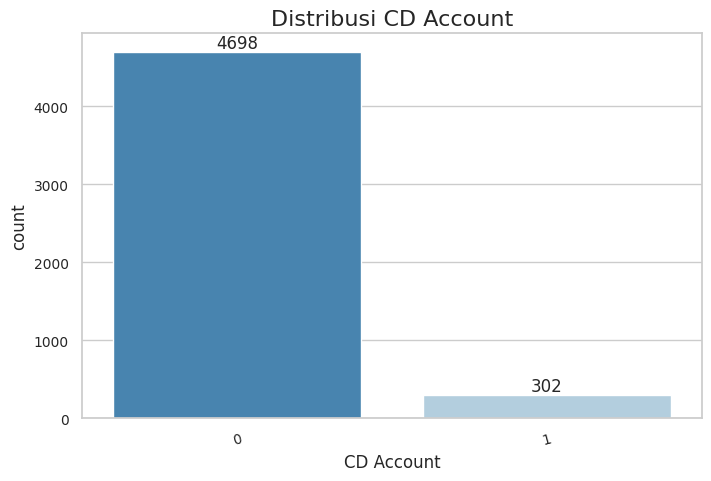

In [84]:
plot_categorical(df, "CD Account")

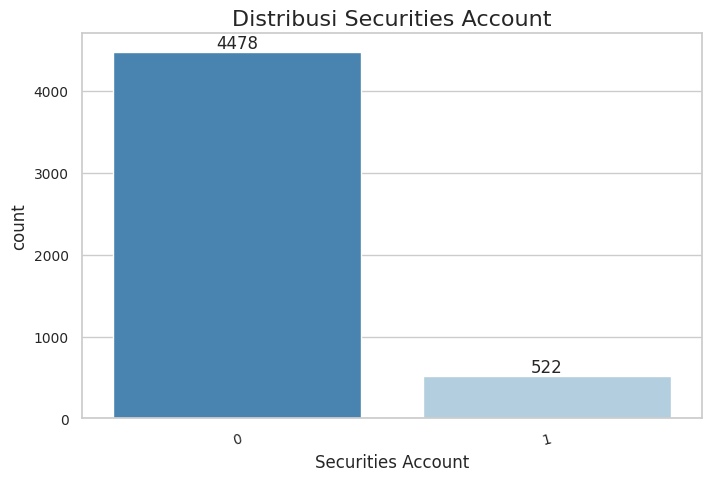

In [85]:
plot_categorical(df, "Securities Account")

### Kesimpulan

Sebagian besar nasabah telah memanfaatkan beberapa layanan perbankan. Tingkat penggunaan produk ini dapat menjadi indikator loyalitas serta kedekatan hubungan nasabah dengan bank.

## 7.4 Personal Loan Acceptance Analysis

Tahap ini bertujuan untuk mengidentifikasi karakteristik nasabah yang memiliki kecenderungan lebih tinggi dalam menerima penawaran Personal Loan.

Analisis dilakukan dengan membandingkan karakteristik setiap kelompok nasabah berdasarkan status penerimaan pinjaman.

### Demografi

Analisis : Age


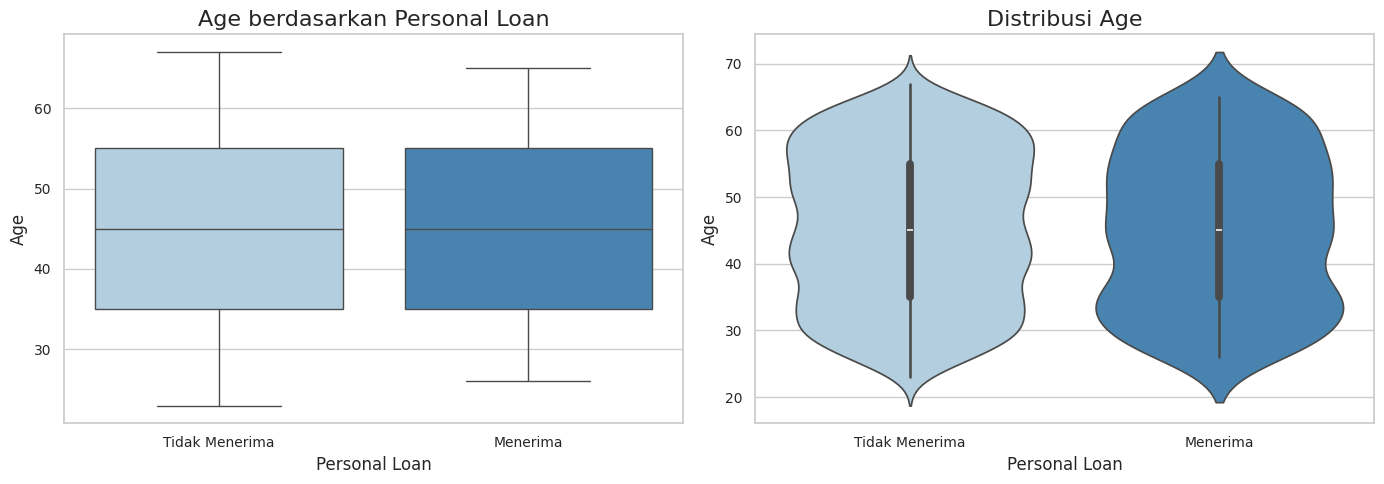

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,45.37,45.00,11.45,23,67
Menerima,480,45.07,45.00,11.59,26,65



> **Insight**

Nasabah yang menerima Personal Loan
cenderung memiliki rata-rata
**Age**
lebih rendah.


In [86]:
analyze_target(df, "Age")

Analisis : Experience


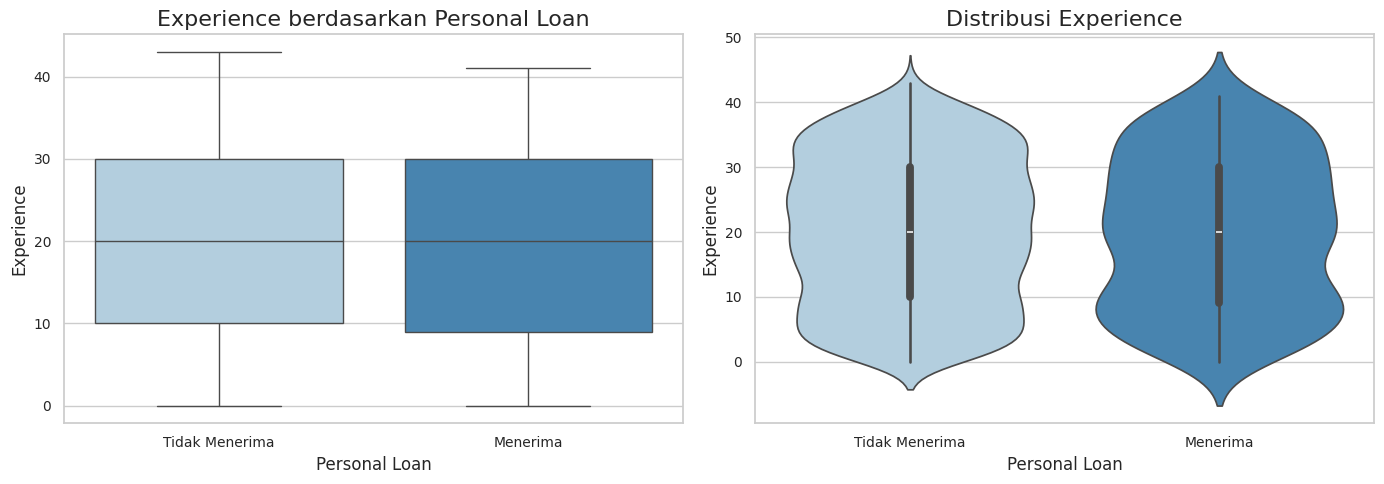

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,20.17,20.00,11.40,0,43
Menerima,480,19.84,20.00,11.58,0,41



> **Insight**

Nasabah yang menerima Personal Loan
cenderung memiliki rata-rata
**Experience**
lebih rendah.


In [87]:
analyze_target(df, "Experience")

Analisis : Family


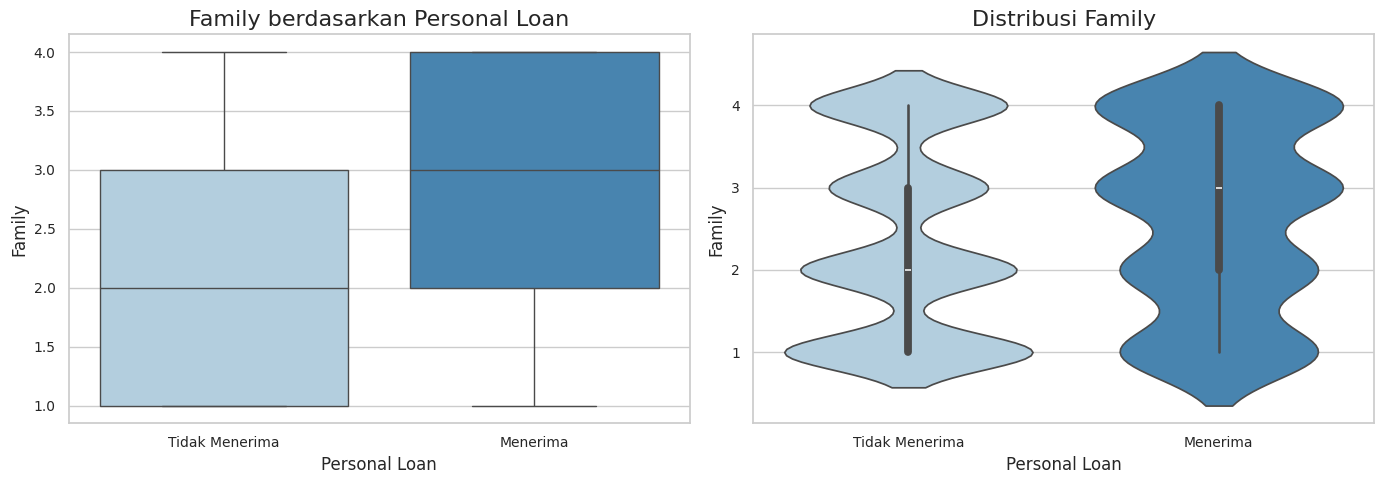

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,2.37,2.00,1.15,1,4
Menerima,480,2.61,3.00,1.12,1,4



> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **Family**
lebih tinggi dibandingkan nasabah
yang tidak menerima.


In [88]:
analyze_target(df, "Family")

Analisis : Education


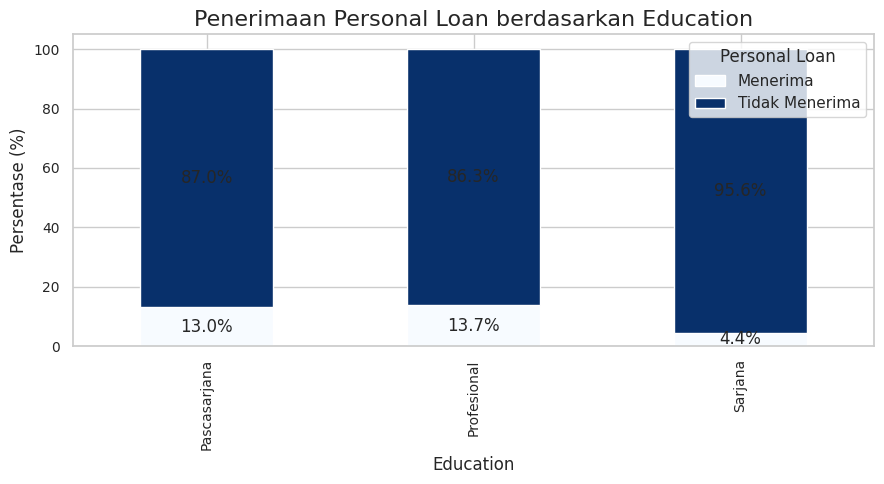

,Tidak Menerima (%),Menerima (%)
Education,,
Pascasarjana,87.03,12.97
Profesional,86.34,13.66
Sarjana,95.56,4.44



> **Insight**

Kelompok **Profesional**
memiliki tingkat penerimaan Personal Loan
tertinggi yaitu
**13.7%**.


In [89]:
analyze_target(df, "Education")

Analisis : Income


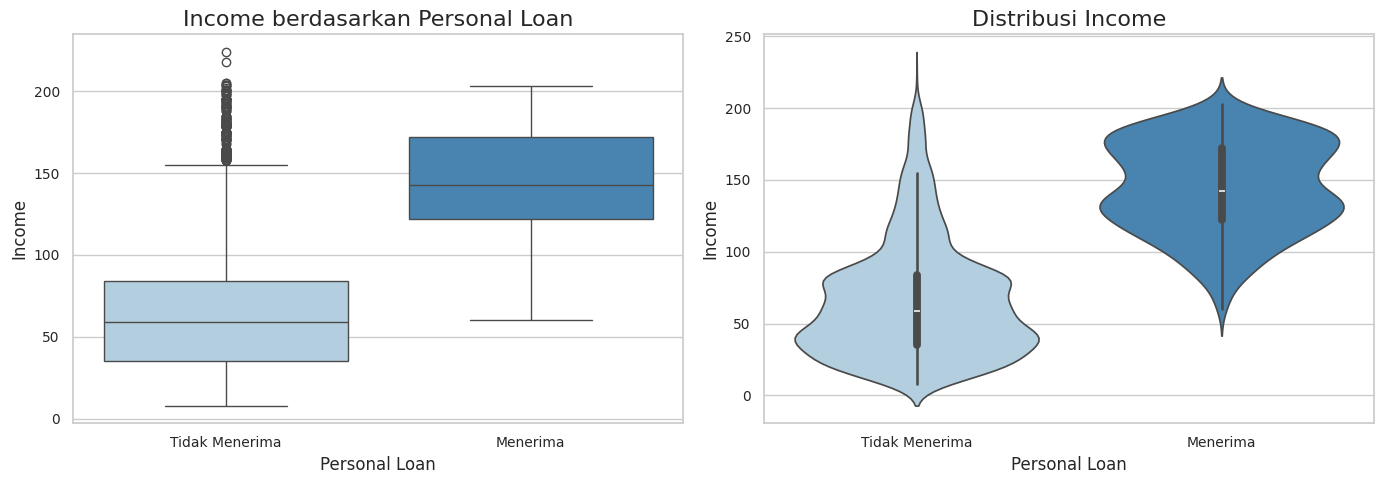

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,66.24,59.00,40.58,8,224
Menerima,480,144.75,142.50,31.58,60,203



> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **Income**
lebih tinggi dibandingkan nasabah
yang tidak menerima.


Analisis : Mortgage


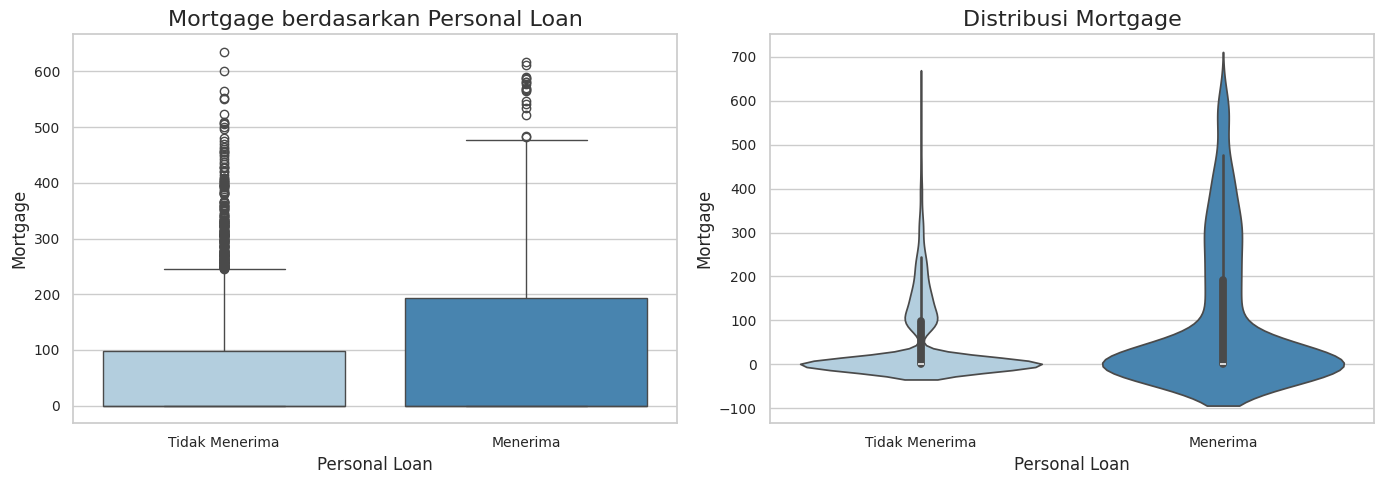

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,51.79,0.00,92.04,0,635
Menerima,480,100.85,0.00,160.85,0,617



> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **Mortgage**
lebih tinggi dibandingkan nasabah
yang tidak menerima.


Analisis : CCAvg


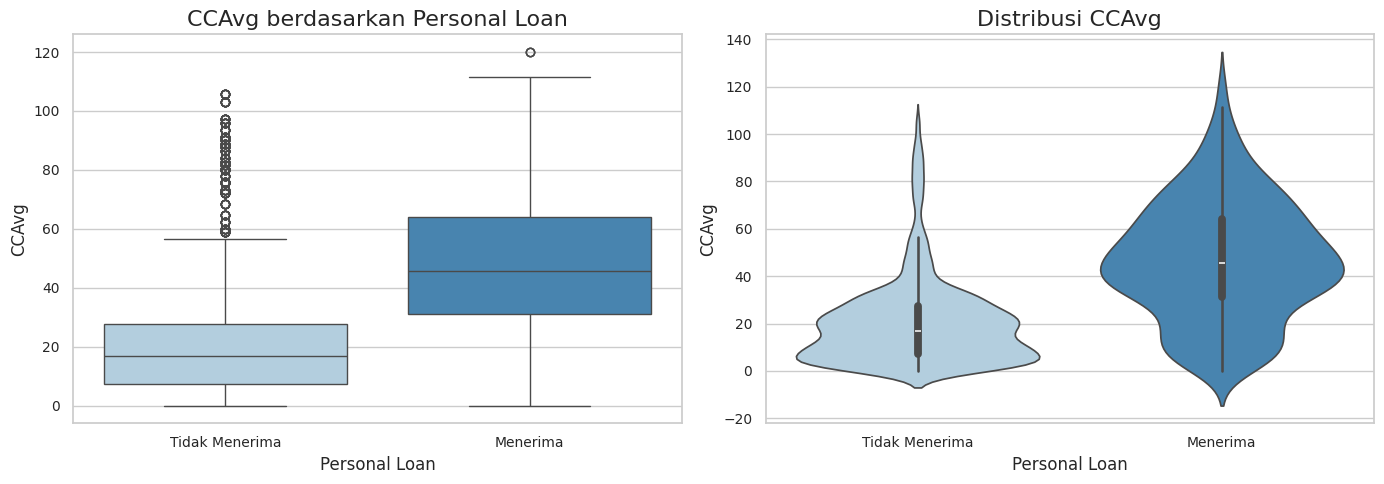

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,20.75,16.80,18.81,0.00,105.60
Menerima,480,46.86,45.60,25.17,0.00,120.00



> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **CCAvg**
lebih tinggi dibandingkan nasabah
yang tidak menerima.


In [90]:
# Finansial
analyze_target(df, "Income")
analyze_target(df, "Mortgage")
analyze_target(df, "CCAvg")

Analisis : Age Group


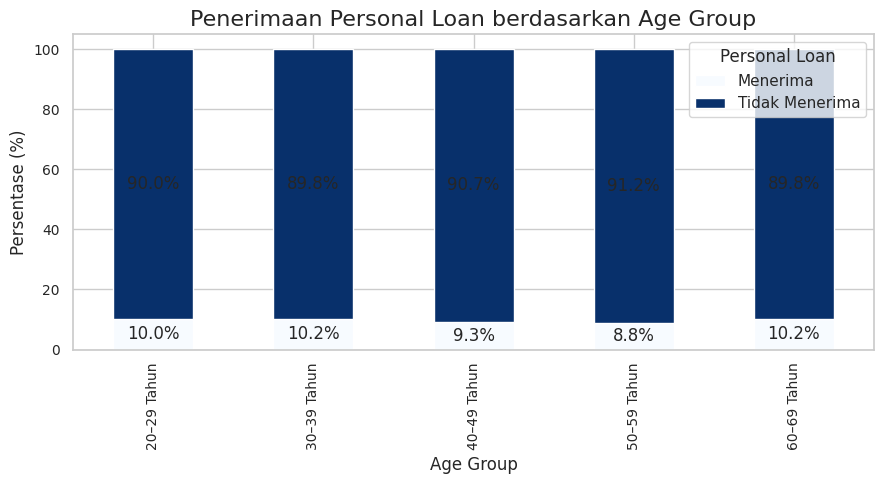

,Tidak Menerima (%),Menerima (%)
Age Group,,
20–29 Tahun,89.96,10.04
30–39 Tahun,89.82,10.18
40–49 Tahun,90.69,9.31
50–59 Tahun,91.15,8.85
60–69 Tahun,89.76,10.24



> **Insight**

Kelompok **60–69 Tahun**
memiliki tingkat penerimaan Personal Loan
tertinggi yaitu
**10.2%**.


Analisis : Income Category


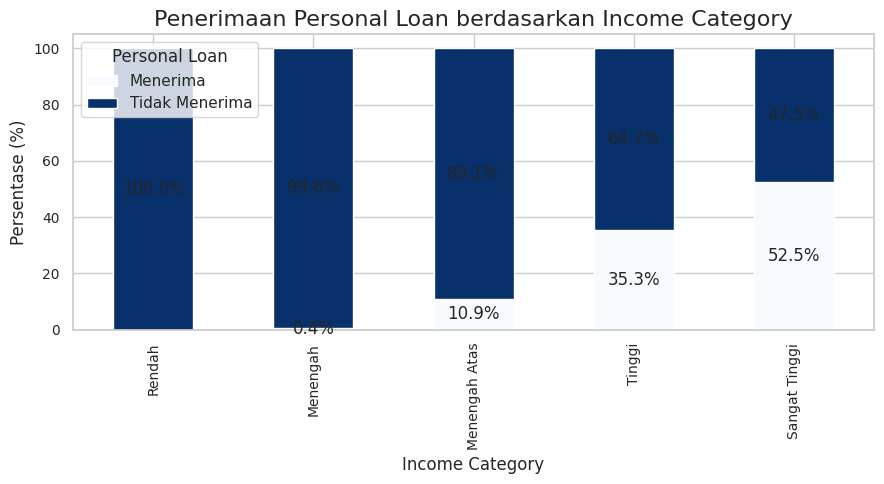

,Tidak Menerima (%),Menerima (%)
Income Category,,
Rendah,100.00,0.00
Menengah,99.60,0.40
Menengah Atas,89.14,10.86
Tinggi,64.73,35.27
Sangat Tinggi,47.46,52.54



> **Insight**

Kelompok **Sangat Tinggi**
memiliki tingkat penerimaan Personal Loan
tertinggi yaitu
**52.5%**.


In [91]:
# Segmentasi
analyze_target(df, "Age Group")
analyze_target(df, "Income Category")

Analisis : Online


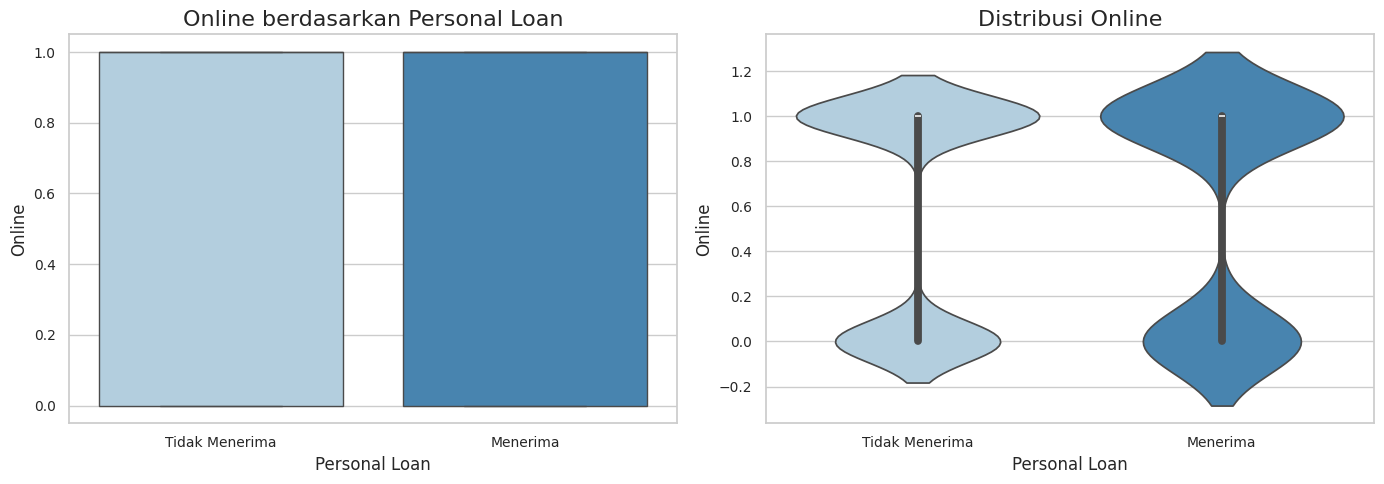

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,0.60,1.00,0.49,0,1
Menerima,480,0.61,1.00,0.49,0,1



> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **Online**
lebih tinggi dibandingkan nasabah
yang tidak menerima.


Analisis : CreditCard


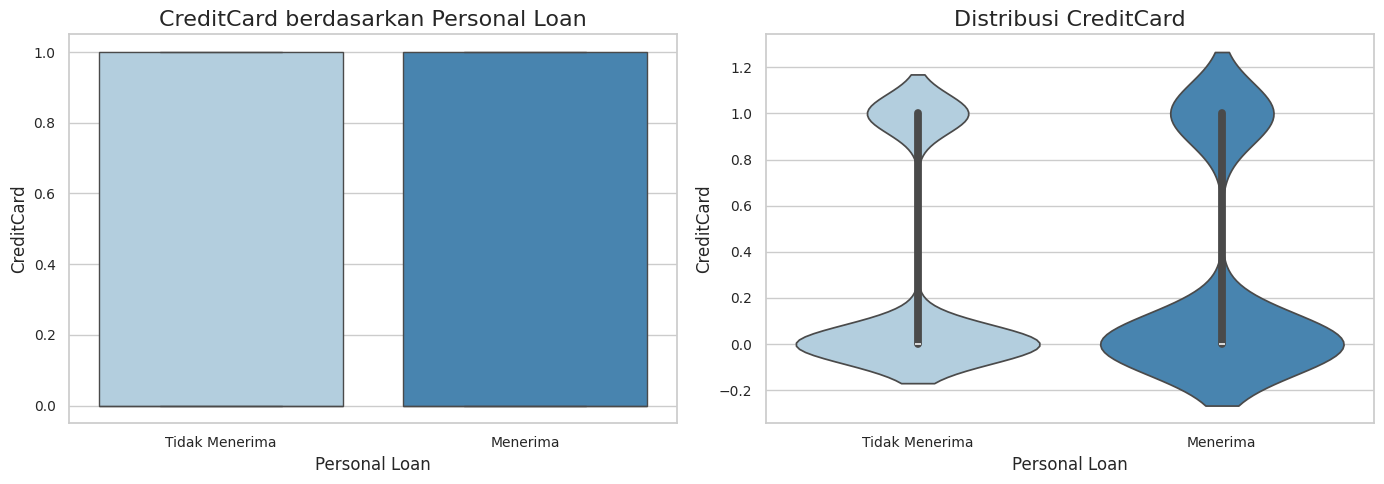

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,0.29,0.00,0.46,0,1
Menerima,480,0.30,0.00,0.46,0,1



> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **CreditCard**
lebih tinggi dibandingkan nasabah
yang tidak menerima.


Analisis : CD Account


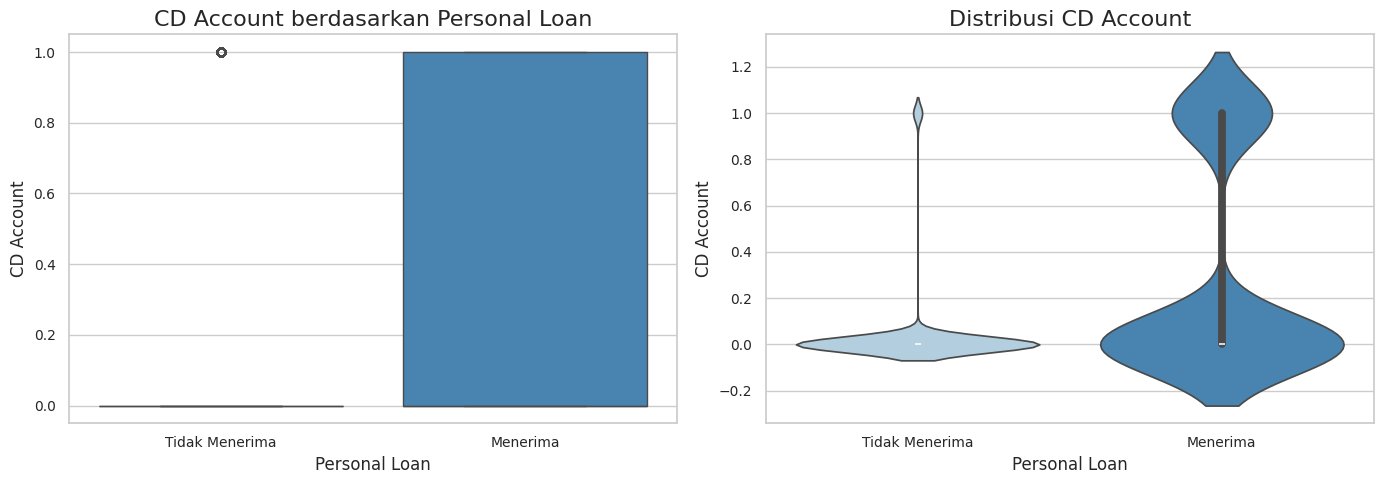

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,0.04,0.00,0.19,0,1
Menerima,480,0.29,0.00,0.46,0,1



> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **CD Account**
lebih tinggi dibandingkan nasabah
yang tidak menerima.


Analisis : Securities Account


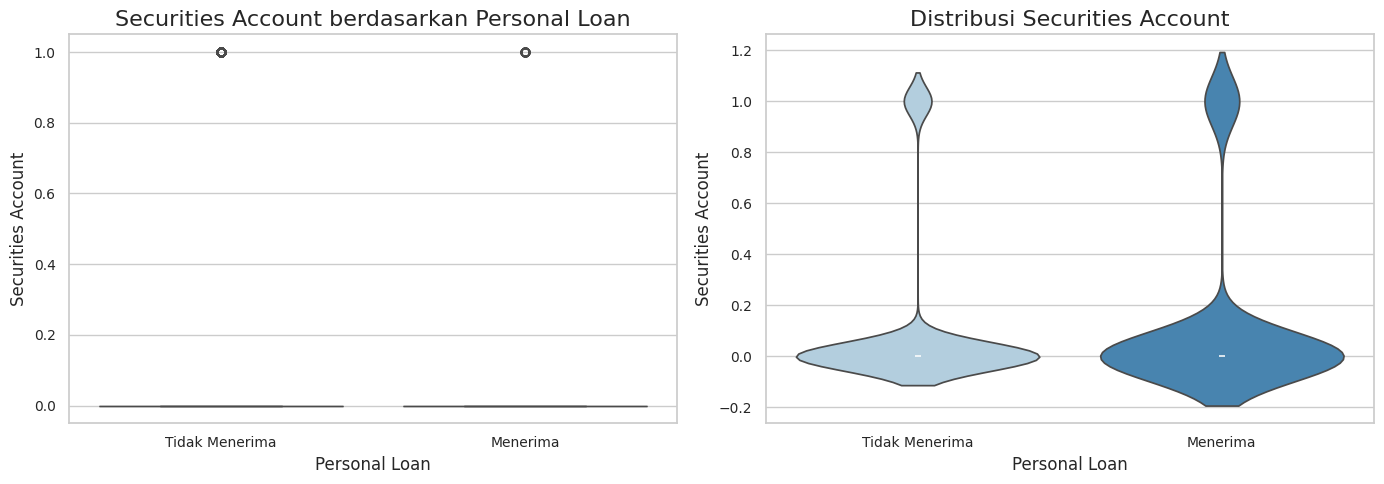

,count,mean,median,std,min,max
Personal Loan,,,,,,
Tidak Menerima,4520,0.10,0.00,0.30,0,1
Menerima,480,0.12,0.00,0.33,0,1



> **Insight**

Nasabah yang **menerima Personal Loan**
memiliki rata-rata **Securities Account**
lebih tinggi dibandingkan nasabah
yang tidak menerima.


In [92]:
# Produk Bank
analyze_target(df, "Online")
analyze_target(df, "CreditCard")
analyze_target(df, "CD Account")
analyze_target(df, "Securities Account")

## 7.5 Correlation Analysis

Analisis korelasi dilakukan untuk melihat hubungan linear antar variabel numerik dalam dataset. Hasil korelasi membantu mengidentifikasi variabel yang saling berkaitan serta memberikan gambaran awal mengenai faktor yang berpotensi memengaruhi penerimaan Personal Loan.

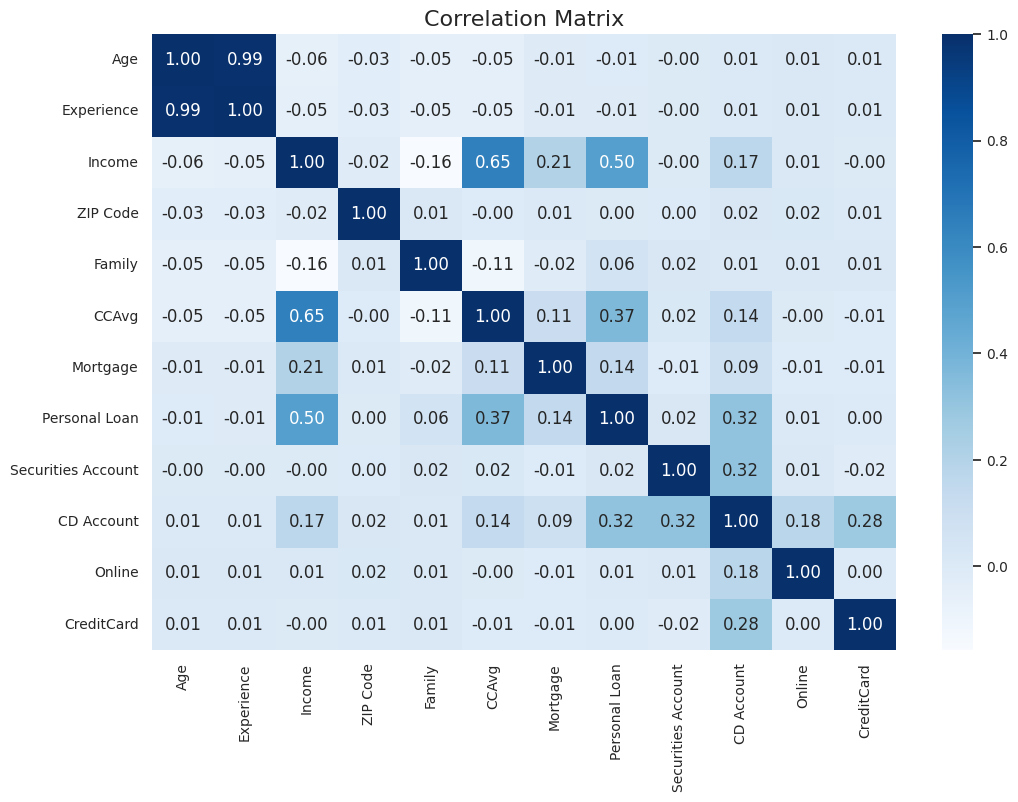

In [93]:
correlation_heatmap(df)

In [94]:
# Menampilkan pasangan variabel dengan korelasi tertinggi
corr_matrix = df.select_dtypes(include=np.number).corr()

corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(10).to_frame(name="Nilai Korelasi")

Nilai Korelasi
Age                Experience               0.99
Income             CCAvg                    0.65
                   Personal Loan            0.50
CCAvg              Personal Loan            0.37
Securities Account CD Account               0.32
Personal Loan      CD Account               0.32
CD Account         CreditCard               0.28
Income             Mortgage                 0.21
CD Account         Online                   0.18
Income             CD Account               0.17

### Kesimpulan

Sebagian besar variabel memiliki korelasi yang rendah hingga sedang, sehingga menunjukkan bahwa masing-masing variabel memberikan informasi yang relatif berbeda. Variabel dengan korelasi lebih tinggi terhadap *Personal Loan* dapat dipertimbangkan sebagai faktor utama dalam penyusunan strategi pemasaran maupun pengembangan model prediksi.

# 1️⃣2️⃣ Business Insight

Berdasarkan hasil Exploratory Data Analysis (EDA), diperoleh beberapa temuan penting yang dapat membantu bank dalam meningkatkan efektivitas pemasaran produk Personal Loan.

---

* **Pendapatan Merupakan Faktor Terkuat**

Nasabah dengan **kategori pendapatan sangat tinggi** memiliki tingkat penerimaan Personal Loan paling tinggi, yaitu **52,54%**.

Hal ini menunjukkan bahwa kemampuan finansial menjadi faktor utama yang memengaruhi keputusan nasabah dalam menerima penawaran pinjaman.

---

* **Pengeluaran Kartu Kredit Mencerminkan Potensi Nasabah**

Nasabah dengan **rata-rata pengeluaran kartu kredit (CCAvg) sangat tinggi** memiliki tingkat penerimaan Personal Loan sebesar **29,01%**.

Temuan ini mengindikasikan bahwa perilaku transaksi yang aktif dapat menjadi indikator kebutuhan terhadap produk pembiayaan.

---

* **Tingkat Pendidikan Berpengaruh terhadap Keputusan Pinjaman**

Kelompok nasabah dengan tingkat pendidikan **Profesional** menunjukkan tingkat penerimaan Personal Loan tertinggi dibandingkan kelompok pendidikan lainnya.

Hal ini mengindikasikan bahwa tingkat pendidikan berpotensi memengaruhi literasi keuangan serta pemahaman terhadap manfaat produk pinjaman.

---

* **Kelompok Usia Senior Memiliki Peluang Lebih Tinggi**

Nasabah pada rentang usia **60–69 tahun** memiliki tingkat penerimaan Personal Loan tertinggi dibandingkan kelompok usia lainnya.

Temuan ini menunjukkan bahwa kebutuhan pembiayaan tidak hanya berasal dari kelompok usia muda, tetapi juga dapat muncul pada nasabah yang telah memasuki usia menjelang pensiun.

---

* **Pendekatan Target Marketing Lebih Efektif**

Hasil analisis menunjukkan bahwa karakteristik nasabah memiliki hubungan yang berbeda terhadap penerimaan Personal Loan.

Oleh karena itu, strategi pemasaran berbasis segmentasi akan lebih efektif dibandingkan memberikan penawaran secara merata kepada seluruh nasabah.

# 1️⃣3️⃣ Business Recommendation

Berdasarkan hasil analisis data, berikut beberapa rekomendasi yang dapat dipertimbangkan oleh pihak bank untuk meningkatkan efektivitas kampanye **Personal Loan**.

---
* **Prioritaskan Nasabah Berpendapatan Tinggi**

Nasabah dengan **kategori pendapatan sangat tinggi** menunjukkan tingkat penerimaan Personal Loan paling tinggi. Oleh karena itu, bank disarankan untuk memprioritaskan segmen ini dalam kampanye pemasaran agar peluang konversi lebih besar dan biaya promosi lebih efisien.

---

* **Manfaatkan Aktivitas Transaksi sebagai Indikator Target**

Nasabah dengan **pengeluaran kartu kredit (CCAvg) yang tinggi** memiliki kecenderungan lebih besar untuk menerima Personal Loan. Bank dapat memanfaatkan informasi aktivitas transaksi sebagai salah satu kriteria dalam menentukan target pemasaran.

---

* **Fokus pada Segmen Nasabah Berpendidikan Tinggi**

Kelompok nasabah dengan tingkat pendidikan **Profesional** memiliki tingkat penerimaan Personal Loan yang lebih tinggi dibandingkan kelompok lainnya. Oleh karena itu, strategi promosi dapat disesuaikan dengan kebutuhan finansial dan karakteristik segmen ini.

---

* **Terapkan Strategi Segmentasi Berdasarkan Profil Nasabah**

Hasil analisis menunjukkan bahwa peluang penerimaan Personal Loan berbeda pada setiap kelompok nasabah. Bank disarankan menerapkan **segmentasi pelanggan** berdasarkan kombinasi karakteristik seperti usia, pendapatan, tingkat pendidikan, dan aktivitas transaksi agar kampanye menjadi lebih tepat sasaran.

---

* **Mengembangkan Model Prediksi Personal Loan**

Sebagai pengembangan lebih lanjut, bank dapat membangun **model machine learning** untuk memprediksi peluang setiap nasabah dalam menerima Personal Loan. Model tersebut dapat digunakan sebagai sistem pendukung keputusan (*decision support system*) sehingga tim pemasaran dapat memfokuskan promosi kepada nasabah dengan probabilitas konversi yang lebih tinggi.

# 1️⃣4️⃣ Conclusion

Berdasarkan hasil analisis terhadap data nasabah **Thera Bank**, dapat disimpulkan bahwa karakteristik pelanggan memiliki hubungan yang berbeda terhadap tingkat penerimaan **Personal Loan**. Faktor-faktor seperti **kategori pendapatan, pengeluaran kartu kredit (CCAvg), tingkat pendidikan,** dan **kelompok usia** menunjukkan keterkaitan yang cukup kuat dengan keputusan nasabah dalam menerima penawaran pinjaman.

Melalui proses **Data Understanding**, **Data Cleaning**, **Descriptive Statistics**, dan **Exploratory Data Analysis (EDA)**, berhasil diperoleh berbagai insight yang dapat digunakan untuk mengidentifikasi segmen pelanggan dengan potensi konversi yang lebih tinggi. Hasil analisis menunjukkan bahwa pendekatan **target marketing** berbasis karakteristik nasabah lebih efektif dibandingkan strategi pemasaran yang dilakukan secara menyeluruh.

Secara keseluruhan, analisis ini membuktikan bahwa pemanfaatan data pelanggan dapat membantu bank dalam memahami perilaku nasabah, meningkatkan efektivitas kampanye pemasaran, serta menjadi dasar dalam pengambilan keputusan bisnis yang lebih tepat. Selain itu, hasil analisis ini juga dapat dikembangkan lebih lanjut sebagai landasan dalam membangun model prediksi penerimaan **Personal Loan** untuk mendukung strategi pemasaran berbasis data pada masa mendatang.

# Biodata Creator

Terima kasih telah mengunjungi portofolio ini.

### Informasi Singkat

**Nama:** Nadhif Fajrul Minan, S.Kom\
**Posisi yang Dilamar:** Data Analyst\
**Bidang:** Data Analytics, Business Intelligence, Machine Learning,
Data Visualization

### Tentang Saya

Saya merupakan lulusan Sarjana Komputer yang memiliki minat pada bidang
analisis data dan pengambilan keputusan berbasis data. Saya memiliki
pengalaman dalam mengolah data, melakukan Exploratory Data Analysis
(EDA), membangun dashboard, serta mengembangkan model analitik
menggunakan Python, SQL, dan berbagai tools pendukung.

Melalui setiap proyek portofolio, saya berusaha tidak hanya menyajikan
visualisasi data, tetapi juga menghasilkan insight dan rekomendasi
bisnis yang dapat mendukung proses pengambilan keputusan.

### Keahlian

-   Python (Pandas, NumPy, Scikit-learn)
-   SQL
-   Data Cleaning & Data Preprocessing
-   Exploratory Data Analysis (EDA)
-   Data Visualization (Matplotlib, Seaborn, Plotly)
-   Dashboard (Power BI / Tableau )
-   Machine Learning & Deep Learning
-   Business Insight & Business Recommendation

### Kontak

📧 **Email:** [nadhifminan@gmail.com](http://[nadhifminan@gmail.com)

💼 **[LinkedIn](http://linkedin.com/in/nadhif-fajrul-minan-9b4088251/)** 

💻 **[GitHub](http://:github.com/nadhifminan)**

🌐 **[Portofolio](http://nadhifminan.github.io/Portofolio):** 

------------------------------------------------------------------------

> Terima kasih telah meluangkan waktu untuk meninjau portofolio ini.
> Saya terbuka terhadap peluang sebagai **Data Analyst** maupun posisi
> lain yang berkaitan dengan analisis data. Saya berharap dapat
> memberikan kontribusi melalui kemampuan analitis, pemecahan masalah,
> dan pengambilan keputusan berbasis data.
